# Fair Heart: Gender Bias Detection and Mitigation in Heart Disease Prediction Models

**Course:** Algorithmic Fairness, Accountability and Ethics — Spring 2026  
**IT University of Copenhagen**

---

## Project overview

This notebook investigates **gender bias** in a heart disease prediction model. We follow a structured pipeline:

1. **Load and explore** the Kaggle Heart Failure Prediction Dataset
2. **Preprocess** the data (encode features, scale, split)
3. **Train a baseline logistic regression** model
4. **Assess fairness** using demographic parity, equalized odds, and TPR/FPR differences
5. **Explain the model** using both its coefficients (whitebox) and SHAP values
6. **Debias** the model using pre-processing, in-processing, and post-processing techniques
7. **Re-evaluate fairness** and discuss the accuracy–fairness tradeoff

### Why logistic regression (whitebox model)?

We deliberately choose logistic regression because it is a **whitebox model**. Unlike black-box models such as random forests or neural networks, logistic regression provides **directly interpretable coefficients**: each coefficient tells us the direction and magnitude of a feature's effect on the predicted log-odds of heart disease. This means we can:

- **Inspect the model's reasoning** without any post-hoc tool — the coefficients *are* the explanation.
- **Identify bias sources** by checking whether the sex coefficient or proxy-feature coefficients push predictions in unfair directions.
- **Layer SHAP on top** to get per-instance and per-group explanations that complement the global coefficient view.

As our professor noted, using a whitebox model is the most appropriate choice for an explainability-focused fairness project because it lets us trace bias back to specific model parameters rather than relying solely on approximation techniques like LIME. With logistic regression, **the model IS the explanation**.

### Dataset context

The dataset contains 918 patient records with 725 males and only 193 females. This gender imbalance mirrors a well-documented problem in cardiology: women are historically underrepresented in cardiac research, leading to ML models that perform worse for female patients. This makes gender fairness analysis particularly relevant and impactful for this dataset.

---
## Step 0: Setup and imports

We import all required libraries:
- `scikit-learn`: logistic regression, evaluation metrics, preprocessing
- `shap`: SHAP values for per-instance feature-level explanations
- `fairlearn`: fairness metrics and debiasing algorithms (Microsoft's fairness toolkit)

**Note:** Unlike the stroke dataset (~5% positive), this dataset is roughly 55/45 balanced, so we do NOT need SMOTE. This simplifies the pipeline and avoids potential issues with synthetic data affecting fairness metrics.

In [ ]:
# Uncomment and run once if packages are not installed
# !pip install pandas numpy matplotlib seaborn scikit-learn shap fairlearn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


---
## Step 1: Data loading and exploratory analysis

The dataset comes from Kaggle (fedesoriano/heart-failure-prediction) and contains 918 patient records with 11 clinical features. It was created by combining five heart disease datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, Statlog).

The **target variable** is `HeartDisease` (1 = heart disease, 0 = normal). Our **protected attribute** is `Sex` (M/F).

**What we look for in EDA:**
- Gender distribution — are groups balanced? (Spoiler: 725 male vs 193 female — significant imbalance)
- Does heart disease prevalence differ between sexes?
- Which features correlate with sex? These are **proxy variables** that could carry gender bias even if sex is removed.

In [3]:
# Load the dataset
df = pd.read_csv('data/heart-failure/heart.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns and types:')
print(df.dtypes)
df.head()

Dataset shape: (918, 12)

Columns and types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Check missing values and class balance
print('=== Missing values ===')
print(df.isnull().sum())
print(f'\nNo missing values — no imputation needed.')

print(f'\n=== Class balance (HeartDisease) ===')
print(df['HeartDisease'].value_counts())
print(f'\nHeart disease prevalence: {df["HeartDisease"].mean()*100:.1f}%')
print('Classes are roughly balanced (~55/45) — no SMOTE needed.')

=== Missing values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No missing values — no imputation needed.

=== Class balance (HeartDisease) ===
HeartDisease
1    508
0    410
Name: count, dtype: int64

Heart disease prevalence: 55.3%
Classes are roughly balanced (~55/45) — no SMOTE needed.


In [5]:
# Gender distribution and heart disease rates
print('=== Sex distribution ===')
print(df['Sex'].value_counts())
print(f'\nMale patients: {(df["Sex"]=="M").sum()} ({(df["Sex"]=="M").mean()*100:.1f}%)')
print(f'Female patients: {(df["Sex"]=="F").sum()} ({(df["Sex"]=="F").mean()*100:.1f}%)')
print('\nWomen are significantly underrepresented — a known problem in cardiac research.')

print(f'\n=== Heart disease rate by sex ===')
disease_by_sex = df.groupby('Sex')['HeartDisease'].agg(['mean', 'sum', 'count'])
disease_by_sex.columns = ['Disease_Rate', 'Disease_Count', 'Total']
print(disease_by_sex)
print('\nNotice the large difference in disease rates between sexes.')

=== Sex distribution ===
Sex
M    725
F    193
Name: count, dtype: int64

Male patients: 725 (79.0%)
Female patients: 193 (21.0%)

Women are significantly underrepresented — a known problem in cardiac research.

=== Heart disease rate by sex ===
     Disease_Rate  Disease_Count  Total
Sex                                    
F        0.259067             50    193
M        0.631724            458    725

Notice the large difference in disease rates between sexes.


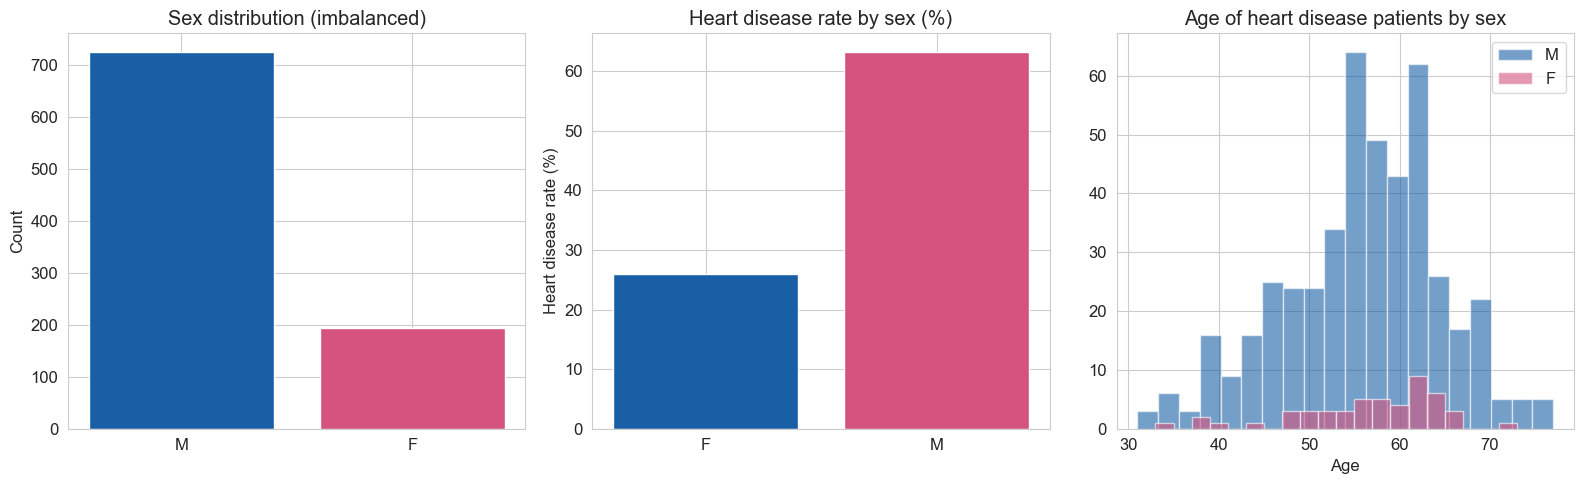

In [6]:
# Visual EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex distribution
sex_counts = df['Sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#185FA5', '#D4537E'])
axes[0].set_title('Sex distribution (imbalanced)')
axes[0].set_ylabel('Count')

# Heart disease rate by sex
disease_rates = df.groupby('Sex')['HeartDisease'].mean() * 100
axes[1].bar(disease_rates.index, disease_rates.values, color=['#185FA5', '#D4537E'])
axes[1].set_title('Heart disease rate by sex (%)')
axes[1].set_ylabel('Heart disease rate (%)')

# Age distribution of disease cases by sex
for sex, color in [('M', '#185FA5'), ('F', '#D4537E')]:
    subset = df[(df['Sex'] == sex) & (df['HeartDisease'] == 1)]
    axes[2].hist(subset['Age'], alpha=0.6, bins=20, label=sex, color=color)
axes[2].set_title('Age of heart disease patients by sex')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

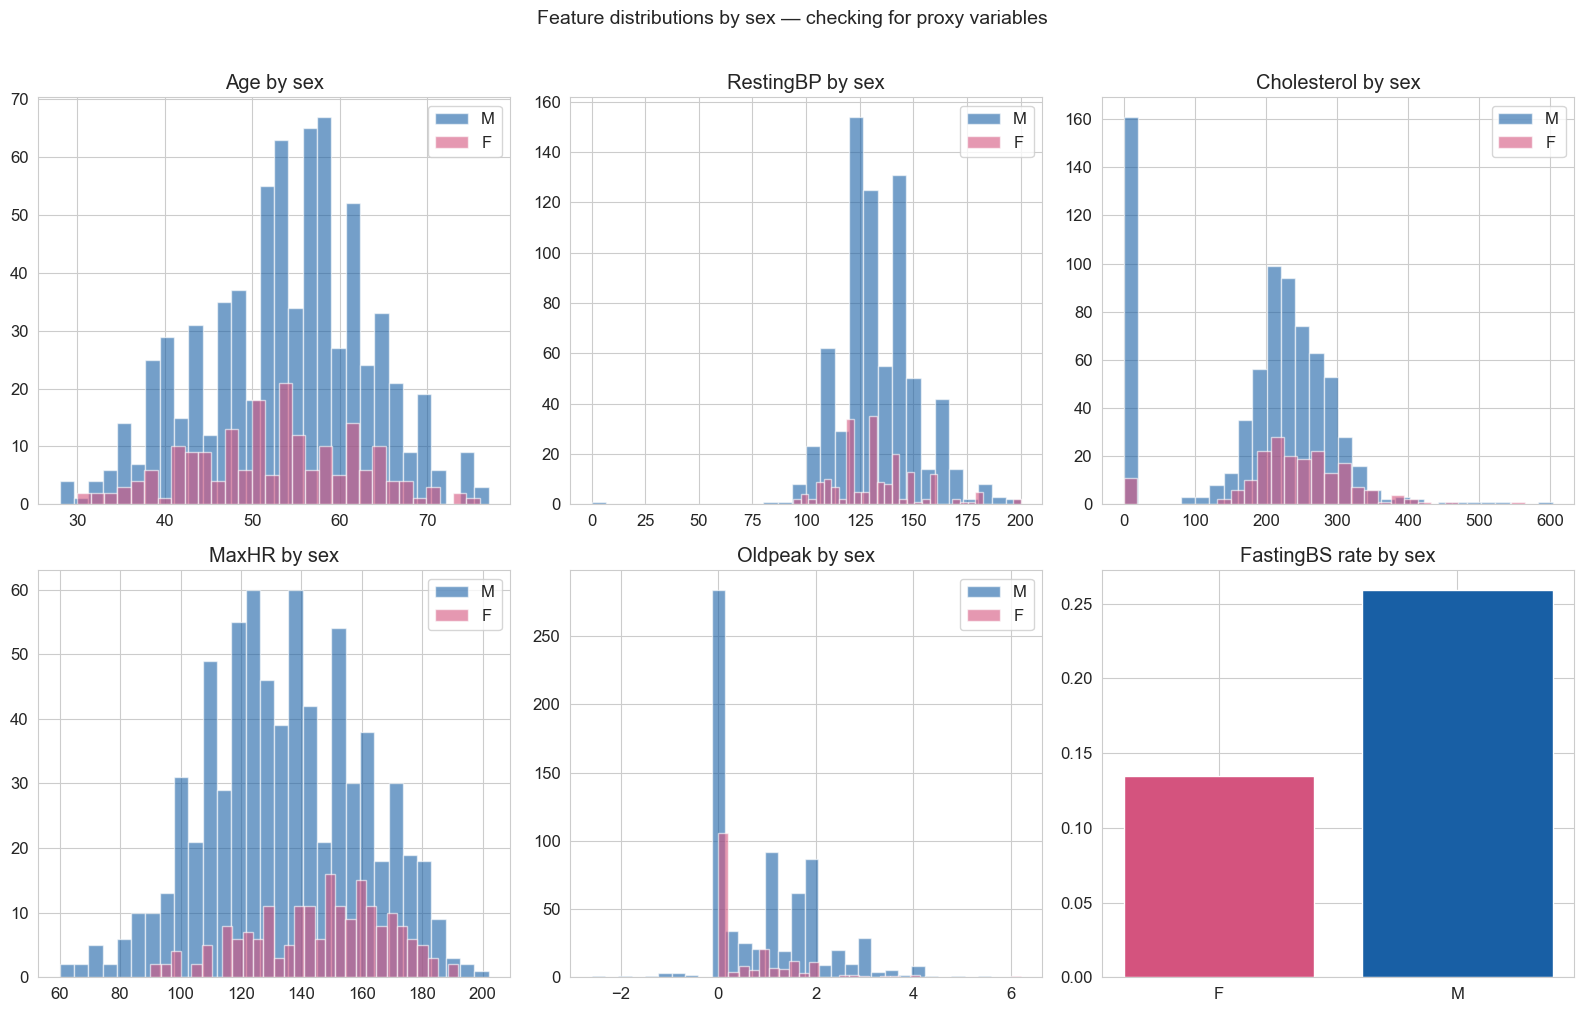

In [7]:
# Feature distributions by sex — checking for proxy variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), ['Age', 'RestingBP', 'Cholesterol',
                                      'MaxHR', 'Oldpeak', 'FastingBS']):
    if col == 'FastingBS':
        ct = df.groupby('Sex')[col].mean()
        ax.bar(ct.index, ct.values, color=['#D4537E', '#185FA5'])
        ax.set_title(f'{col} rate by sex')
    else:
        for sex, color in [('M', '#185FA5'), ('F', '#D4537E')]:
            subset = df[df['Sex'] == sex]
            ax.hist(subset[col].dropna(), alpha=0.6, bins=30, label=sex, color=color)
        ax.set_title(f'{col} by sex')
        ax.legend()

plt.suptitle('Feature distributions by sex — checking for proxy variables', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2: Data preprocessing

**Why each step:**
1. **Encode categoricals** — logistic regression needs numeric inputs. We label-encode `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
2. **Stratified train/test split** — preserves the ~55% heart disease ratio in both sets.
3. **StandardScaler** — logistic regression is scale-sensitive; without scaling, features like `Cholesterol` (range 0–600) would dominate `FastingBS` (0/1).

**What we do NOT need:**
- No missing value imputation (dataset is complete)
- No SMOTE (classes are already ~55/45 balanced)
- No row dropping (no "Other" gender category)

This cleaner pipeline avoids introducing synthetic data artifacts that could interfere with fairness analysis.

In [8]:
data = df.copy()

# Save the protected attribute BEFORE encoding
# M=1, F=0 — this is our sensitive feature for fairness analysis
data['sex_binary'] = data['Sex'].map({'M': 1, 'F': 0})

print(f'Dataset: {len(data)} rows, no missing values')
print(f'Sex: Male={int(data["sex_binary"].sum())}, Female={int((data["sex_binary"]==0).sum())}')

Dataset: 918 rows, no missing values
Sex: Male=725, Female=193


In [9]:
# Encode all categorical columns with LabelEncoder
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}


In [10]:
# Define features, target, and sensitive attribute
X = data.drop(['HeartDisease', 'sex_binary'], axis=1)
y = data['HeartDisease']
sensitive_feature = data['sex_binary']  # M=1, F=0
feature_names = X.columns.tolist()

print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Target: HeartDisease (0={int((y==0).sum())}, 1={int((y==1).sum())})')

# Stratified train/test split
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} ({y_train.mean()*100:.1f}% disease)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean()*100:.1f}% disease)')
print(f'Sex in test: Male={int((sf_test==1).sum())}, Female={int((sf_test==0).sum())}')

Features (11): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
Target: HeartDisease (0=410, 1=508)

Train: 734 (55.3% disease)
Test:  184 (55.4% disease)
Sex in test: Male=146, Female=38


In [12]:
# Scale features — fit on train, transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)


---
## Step 3: Baseline logistic regression

We train a standard logistic regression **without any fairness intervention**. This is our baseline — we need to know *how biased the model is before debiasing* so we can measure improvement.

### Why logistic regression is a whitebox model

Logistic regression predicts: `P(heart_disease) = sigmoid(w1*Age + w2*Sex + w3*Cholesterol + ... + b)`

Each weight w_i directly tells us:
- **Sign**: positive = increases heart disease risk, negative = decreases
- **Magnitude**: larger absolute value = stronger influence

This is fundamentally different from black-box models. Here, **the model IS the explanation** — we can read off exactly how much the `Sex` coefficient contributes to each prediction.

We still use SHAP because:
1. SHAP shows **per-instance** contributions (not just global coefficients)
2. SHAP lets us **compare across gender groups** visually
3. For linear models, LinearExplainer gives **exact** Shapley values — no approximation

In [13]:
# Train the baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
baseline_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print('=== Baseline model — overall performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_baseline):.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=['No Disease', 'Heart Disease']))

=== Baseline model — overall performance ===
Accuracy:  0.8696
Precision: 0.8482
Recall:    0.9314
F1 Score:  0.8879
AUC-ROC:   0.8971

               precision    recall  f1-score   support

   No Disease       0.90      0.79      0.84        82
Heart Disease       0.85      0.93      0.89       102

     accuracy                           0.87       184
    macro avg       0.88      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184



In [14]:
# Performance SPLIT BY SEX — looking for disparities
print('=== Performance by sex ===')
print('We compare metrics between Male and Female to detect bias.\n')

for sex_val, sex_name in [(1, 'Male'), (0, 'Female')]:
    mask = sf_test == sex_val
    y_true_g, y_pred_g = y_test[mask], y_pred_baseline[mask]
    y_prob_g = y_prob_baseline[mask]
    print(f'--- {sex_name} (n={int(mask.sum())}) ---')
    print(f'  Accuracy:  {accuracy_score(y_true_g, y_pred_g):.4f}')
    print(f'  Precision: {precision_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  Recall:    {recall_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  F1:        {f1_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    if len(np.unique(y_true_g)) > 1:
        print(f'  AUC-ROC:   {roc_auc_score(y_true_g, y_prob_g):.4f}')
    print()

=== Performance by sex ===
We compare metrics between Male and Female to detect bias.

--- Male (n=146) ---
  Accuracy:  0.8630
  Precision: 0.8654
  Recall:    0.9375
  F1:        0.9000
  AUC-ROC:   0.8602

--- Female (n=38) ---
  Accuracy:  0.8947
  Precision: 0.6250
  Recall:    0.8333
  F1:        0.7143
  AUC-ROC:   0.9427



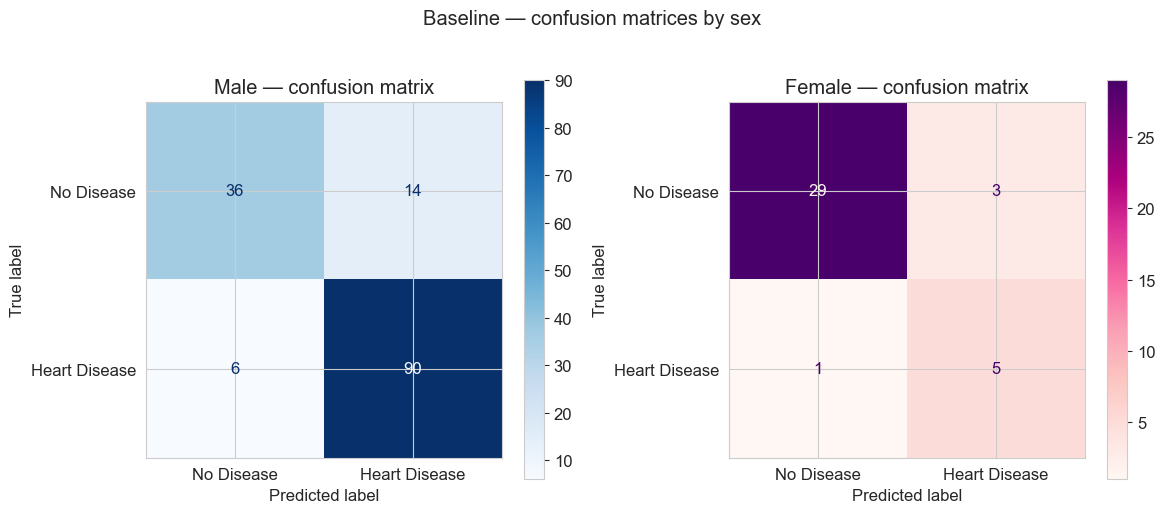

Compare TP and FN cells across sexes.
If one sex has lower TP, the model is missing heart disease for that group.
In cardiology, missed diagnosis in women is a documented real-world problem.


In [15]:
# Confusion matrices by sex
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gval, gname, cmap) in zip(axes, [(1, 'Male', 'Blues'), (0, 'Female', 'RdPu')]):
    mask = sf_test == gval
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], y_pred_baseline[mask],
        display_labels=['No Disease', 'Heart Disease'], cmap=cmap, ax=ax)
    ax.set_title(f'{gname} — confusion matrix')
plt.suptitle('Baseline — confusion matrices by sex', y=1.02)
plt.tight_layout()
plt.show()
print('Compare TP and FN cells across sexes.')
print('If one sex has lower TP, the model is missing heart disease for that group.')
print('In cardiology, missed diagnosis in women is a documented real-world problem.')

---
## Step 4: Fairness assessment (before debiasing)

We measure fairness with sex as the **protected attribute**:

| Metric | What it measures | Healthcare relevance |
|--------|-----------------|---------------------|
| **Demographic parity diff** | Equal prediction rates? | One sex flagged more = more unnecessary testing |
| **Equal opportunity (TPR diff)** | Equal disease detection? | Lower TPR for women = missed diagnoses = delayed treatment |
| **Equalized odds diff** | Equal TPR AND FPR? | Both error types carry costs that shouldn't fall on one sex |
| **FPR difference** | Equal false alarm rates? | More FP = unnecessary anxiety, invasive procedures |

**Primary metric: equalized odds** — in healthcare, both missed diagnoses (FN) and false alarms (FP) have serious consequences.

**Why FN is especially harmful here:** A false negative means a patient with heart disease is told they are healthy. For women, this is particularly dangerous because heart disease symptoms in women are often atypical and already underdiagnosed. A biased model that misses female heart disease reinforces this existing clinical gap.

**Fair threshold: |diff| <= 0.05 (5%)**

In [16]:
def compute_fairness_metrics(y_true, y_pred, sensitive, label='Model'):
    """Compute and display key fairness metrics."""
    metrics_dict = {
        'accuracy': accuracy_score,
        'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
        'recall (TPR)': lambda yt, yp: recall_score(yt, yp, zero_division=0),
        'f1': lambda yt, yp: f1_score(yt, yp, zero_division=0),
        'selection_rate': lambda yt, yp: np.mean(yp),
    }
    mf = MetricFrame(metrics=metrics_dict, y_true=y_true, y_pred=y_pred,
                     sensitive_features=sensitive)
    print(f'\n{"="*65}')
    print(f'  FAIRNESS REPORT: {label}')
    print(f'{"="*65}')
    group_df = mf.by_group.copy()
    group_df.index = ['Female', 'Male']
    print(f'\nPer-group metrics:')
    print(group_df.round(4).to_string())

    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)

    results = {}
    for gval, gname in [(0, 'Female'), (1, 'Male')]:
        mask = sensitive == gval
        yt, yp = y_true[mask], y_pred[mask]
        tp = int(((yp == 1) & (yt == 1)).sum())
        fn = int(((yp == 0) & (yt == 1)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum())
        tn = int(((yp == 0) & (yt == 0)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[gname] = {'TPR': tpr, 'FPR': fpr, 'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn}

    tpr_diff = results['Male']['TPR'] - results['Female']['TPR']
    fpr_diff = results['Male']['FPR'] - results['Female']['FPR']

    tag = lambda d: '[FAIR]' if abs(d) <= 0.05 else '[UNFAIR]'
    print(f'\n--- Fairness differences (Male - Female) ---')
    print(f'  Demographic parity diff: {dp_diff:+.4f}  {tag(dp_diff)}')
    print(f'  Equalized odds diff:     {eo_diff:+.4f}  {tag(eo_diff)}')
    print(f'  TPR diff (M - F):        {tpr_diff:+.4f}  {tag(tpr_diff)}')
    print(f'  FPR diff (M - F):        {fpr_diff:+.4f}  {tag(fpr_diff)}')

    print(f'\n--- Per-group confusion matrix ---')
    for gname in ['Male', 'Female']:
        r = results[gname]
        print(f'  {gname}: TPR={r["TPR"]:.4f}, FPR={r["FPR"]:.4f} '
              f'(TP={r["TP"]}, FN={r["FN"]}, FP={r["FP"]}, TN={r["TN"]})')

    return {'dp_diff': dp_diff, 'eo_diff': eo_diff, 'tpr_diff': tpr_diff,
            'fpr_diff': fpr_diff, 'accuracy': accuracy_score(y_true, y_pred),
            'group_rates': results}

In [17]:
# Compute baseline fairness metrics
baseline_fairness = compute_fairness_metrics(
    y_test.values, y_pred_baseline, sf_test.values,
    label='Baseline logistic regression'
)


  FAIRNESS REPORT: Baseline logistic regression

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.8947     0.6250        0.8333  0.7143          0.2105
Male      0.8630     0.8654        0.9375  0.9000          0.7123

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.5018  [UNFAIR]
  Equalized odds diff:     +0.1863  [UNFAIR]
  TPR diff (M - F):        +0.1042  [UNFAIR]
  FPR diff (M - F):        +0.1863  [UNFAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.9375, FPR=0.2800 (TP=90, FN=6, FP=14, TN=36)
  Female: TPR=0.8333, FPR=0.0938 (TP=5, FN=1, FP=3, TN=29)


---
## Step 5: Explainability — whitebox coefficients + SHAP

Since logistic regression is a **whitebox model**, we have two complementary layers:

### Layer 1: Model coefficients (global, inherent to the model)
Each coefficient directly represents the feature's contribution to log-odds of heart disease. A positive coefficient for `Sex` means one sex is predicted as higher risk. **No external tool needed — the model explains itself.** This is the key advantage of choosing a whitebox model.

### Layer 2: SHAP values (per-instance, per-group)
SHAP complements the coefficients by showing:
- Per-instance contributions (not just global averages)
- How contributions **differ between male and female patients** — crucial for bias analysis
- Whether **proxy features** carry hidden gender bias

For logistic regression, `LinearExplainer` gives **exact** Shapley values — no approximation. Another benefit of the whitebox choice.

=== Logistic regression coefficients (whitebox explanation) ===
Positive = increases heart disease risk. Negative = decreases.

       Feature  Coefficient
      ST_Slope    -1.204104
 ChestPainType    -0.702255
ExerciseAngina     0.536199
           Sex     0.476509
   Cholesterol    -0.474871
     FastingBS     0.438204
       Oldpeak     0.253479
         MaxHR    -0.243404
    RestingECG    -0.157095
     RestingBP     0.067722
           Age     0.042982

>>> Sex coefficient: +0.4765
    Because this is a whitebox model, we can directly read how
    the model weighs sex — no approximation tool needed.


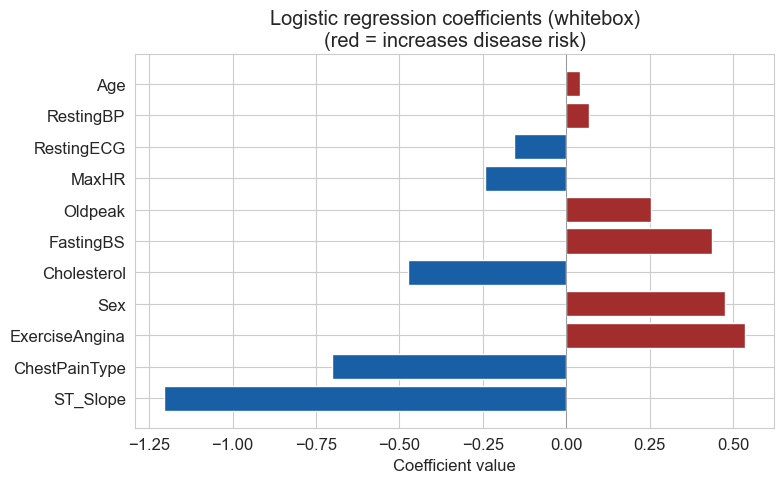

In [18]:
# LAYER 1: Whitebox coefficients — the model's reasoning, directly readable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Logistic regression coefficients (whitebox explanation) ===')
print('Positive = increases heart disease risk. Negative = decreases.\n')
print(coef_df.to_string(index=False))

sex_idx = feature_names.index('Sex')
print(f'\n>>> Sex coefficient: {baseline_model.coef_[0][sex_idx]:+.4f}')
print('    Because this is a whitebox model, we can directly read how')
print('    the model weighs sex — no approximation tool needed.')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#A32D2D' if c > 0 else '#185FA5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic regression coefficients (whitebox)\n(red = increases disease risk)')
ax.axvline(x=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

SHAP values computed for 184 test samples.

Global SHAP summary — each dot is one patient:


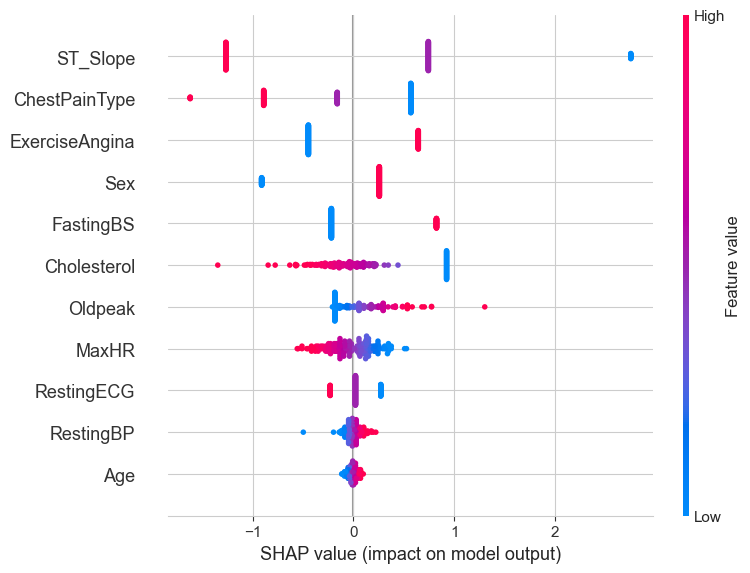

In [19]:
# LAYER 2: SHAP — exact values via LinearExplainer
explainer = shap.LinearExplainer(baseline_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)
print(f'SHAP values computed for {shap_values.shape[0]} test samples.')
print('\nGlobal SHAP summary — each dot is one patient:')
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=True)

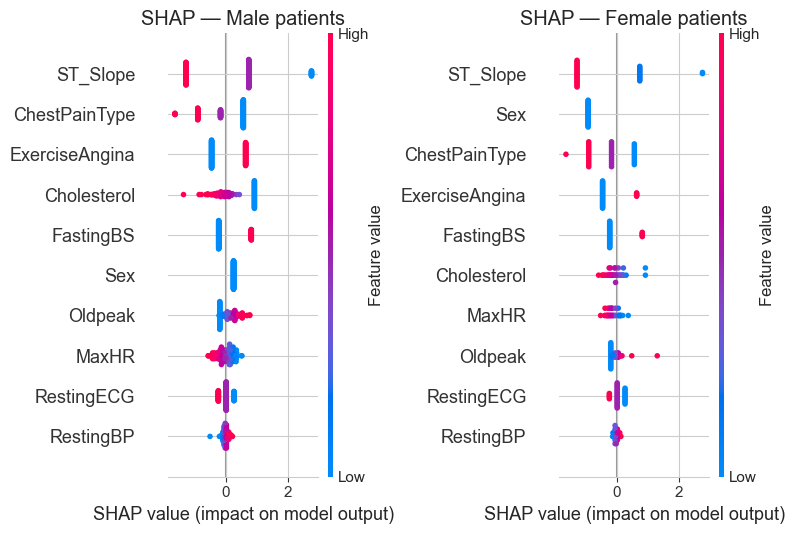

Compare: features ranking differently between sexes contribute to the fairness gap.


In [20]:
# SHAP split by sex — THE KEY FAIRNESS ANALYSIS
male_mask = sf_test.values == 1
female_mask = sf_test.values == 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values[male_mask], X_test_scaled[male_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[0].set_title('SHAP — Male patients')
plt.sca(axes[1])
shap.summary_plot(shap_values[female_mask], X_test_scaled[female_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[1].set_title('SHAP — Female patients')
plt.tight_layout()
plt.show()
print('Compare: features ranking differently between sexes contribute to the fairness gap.')

=== Mean |SHAP| by sex ===
       Feature   Male  Female    Diff
           Sex 0.2569  0.9107 -0.6538
   Cholesterol 0.4033  0.2284  0.1748
     FastingBS 0.3848  0.3146  0.0702
ExerciseAngina 0.5360  0.4730  0.0629
 ChestPainType 0.6151  0.5670  0.0481
       Oldpeak 0.2195  0.1792  0.0403
      ST_Slope 1.1472  1.1654 -0.0182
    RestingECG 0.1163  0.1338 -0.0176
         MaxHR 0.1868  0.1955 -0.0087
           Age 0.0330  0.0374 -0.0044
     RestingBP 0.0529  0.0540 -0.0011


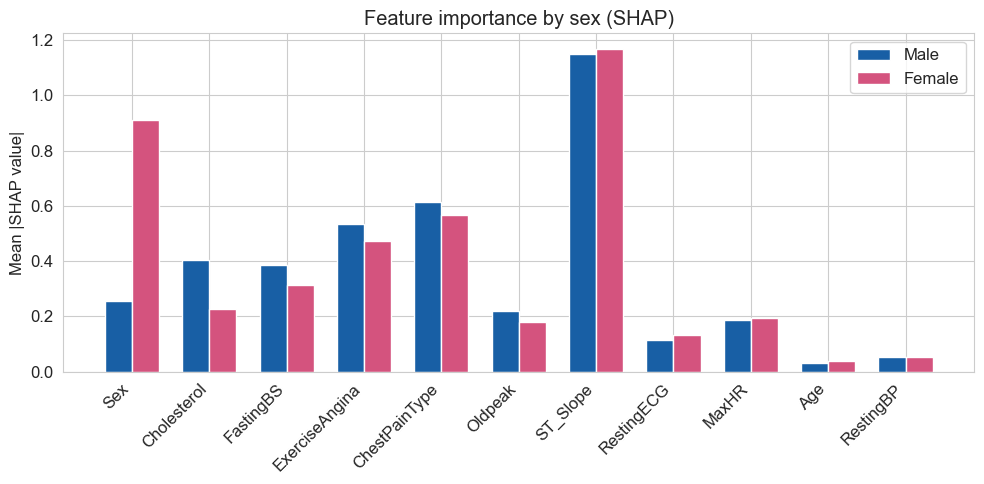


=== Feature correlation with sex (proxy detection) ===
Sex               1.0000
Cholesterol      -0.2001
ExerciseAngina    0.1907
MaxHR            -0.1892
ST_Slope         -0.1507
ChestPainType    -0.1266
FastingBS         0.1201
Oldpeak           0.1057
RestingECG        0.0716
Age               0.0558
RestingBP         0.0051
Name: sex_binary, dtype: float64

Proxy features (|r| > 0.15): ['Sex', 'Cholesterol', 'MaxHR', 'ExerciseAngina', 'ST_Slope']


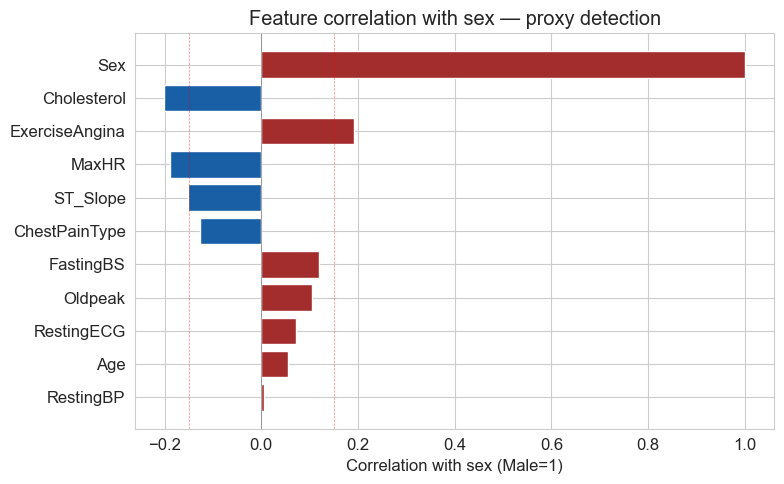

In [22]:
# Quantify SHAP differences + proxy feature detection
shap_male = np.abs(shap_values[male_mask]).mean(axis=0)
shap_female = np.abs(shap_values[female_mask]).mean(axis=0)
shap_comp = pd.DataFrame({'Feature': feature_names, 'Male': shap_male,
    'Female': shap_female, 'Diff': shap_male - shap_female
}).sort_values('Diff', key=abs, ascending=False)
print('=== Mean |SHAP| by sex ===')
print(shap_comp.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(shap_comp))
w = 0.35
ax.bar(x - w/2, shap_comp['Male'], w, label='Male', color='#185FA5')
ax.bar(x + w/2, shap_comp['Female'], w, label='Female', color='#D4537E')
ax.set_xticks(x)
ax.set_xticklabels(shap_comp['Feature'], rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Feature importance by sex (SHAP)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== Feature correlation with sex (proxy detection) ===')
gender_corr = data[feature_names + ['sex_binary']].corr()['sex_binary'].drop('sex_binary')
print(gender_corr.sort_values(key=abs, ascending=False).round(4))
proxy_features = gender_corr[gender_corr.abs() > 0.15].index.tolist()
print(f'\nProxy features (|r| > 0.15): {proxy_features}')

fig, ax = plt.subplots(figsize=(8, 5))
sorted_corr = gender_corr.sort_values(key=abs, ascending=True)
colors = ['#A32D2D' if c > 0 else '#185FA5' for c in sorted_corr.values]
ax.barh(sorted_corr.index, sorted_corr.values, color=colors)
ax.set_xlabel('Correlation with sex (Male=1)')
ax.set_title('Feature correlation with sex — proxy detection')
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.axvline(x=0.15, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(x=-0.15, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Step 6: Debiasing

We apply **three debiasing strategies** at different pipeline stages:

| Approach | Stage | Method | Tradeoff |
|----------|-------|--------|----------|
| **Pre-processing** | Before training | Remove Sex + proxy features | Loses information |
| **In-processing** | During training | ExponentiatedGradient with EqualizedOdds constraint | Constrains optimisation |
| **Post-processing** | After training | ThresholdOptimizer — per-group thresholds | Needs sex at prediction time |

As our professor emphasised: **accuracy reduction is acceptable — the goal is fairness improvement.** If debiasing reduces accuracy but improves fairness, that demonstrates the tradeoff and is a valid result.

### 6a. Pre-processing: remove sex and proxy features

The simplest approach: if the model cannot see sex or features correlated with sex, it cannot (directly) discriminate. We remove the encoded `Sex` column and any feature with |correlation| > 0.15 with sex.

In [23]:
features_to_remove = list(set(proxy_features + ['Sex']))
keep_features = [f for f in feature_names if f not in features_to_remove]
print(f'Removing: {features_to_remove}')
print(f'Keeping ({len(keep_features)}): {keep_features}')

scaler_pre = StandardScaler()
X_train_pre = pd.DataFrame(scaler_pre.fit_transform(X_train[keep_features]),
                            columns=keep_features, index=X_train.index)
X_test_pre = pd.DataFrame(scaler_pre.transform(X_test[keep_features]),
                           columns=keep_features, index=X_test.index)

preproc_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
preproc_model.fit(X_train_pre, y_train)
y_pred_preproc = preproc_model.predict(X_test_pre)

preproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_preproc, sf_test.values,
    label='Pre-processing (remove Sex + proxies)')

Removing: ['Sex', 'MaxHR', 'Cholesterol', 'ExerciseAngina', 'ST_Slope']
Keeping (6): ['Age', 'ChestPainType', 'RestingBP', 'FastingBS', 'RestingECG', 'Oldpeak']

  FAIRNESS REPORT: Pre-processing (remove Sex + proxies)

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.8158     0.4444        0.6667  0.5333          0.2368
Male      0.7877     0.8652        0.8021  0.8324          0.6096

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.3727  [UNFAIR]
  Equalized odds diff:     +0.1354  [UNFAIR]
  TPR diff (M - F):        +0.1354  [UNFAIR]
  FPR diff (M - F):        +0.0837  [UNFAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.8021, FPR=0.2400 (TP=77, FN=19, FP=12, TN=38)
  Female: TPR=0.6667, FPR=0.1562 (TP=4, FN=2, FP=5, TN=27)


### 6b. In-processing: ExponentiatedGradient with equalized odds

This approach modifies training itself. Fairlearn's `ExponentiatedGradient` trains multiple logistic regressions and combines them to satisfy an equalized-odds constraint — ensuring TPR and FPR are approximately equal across sexes.

In [24]:
scaler_in = StandardScaler()
X_train_in = pd.DataFrame(scaler_in.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_in = pd.DataFrame(scaler_in.transform(X_test), columns=feature_names, index=X_test.index)

inproc_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=EqualizedOdds(), max_iter=50)
inproc_model.fit(X_train_in, y_train, sensitive_features=sf_train)
y_pred_inproc = inproc_model.predict(X_test_in)

inproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_inproc, sf_test.values,
    label='In-processing (ExponentiatedGradient + EqualizedOdds)')


  FAIRNESS REPORT: In-processing (ExponentiatedGradient + EqualizedOdds)

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.8158     0.4545        0.8333  0.5882          0.2895
Male      0.8288     0.8660        0.8750  0.8705          0.6644

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.3749  [UNFAIR]
  Equalized odds diff:     +0.0725  [UNFAIR]
  TPR diff (M - F):        +0.0417  [FAIR]
  FPR diff (M - F):        +0.0725  [UNFAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.8750, FPR=0.2600 (TP=84, FN=12, FP=13, TN=37)
  Female: TPR=0.8333, FPR=0.1875 (TP=5, FN=1, FP=6, TN=26)


### 6c. Post-processing: ThresholdOptimizer

Keeps the original model but adjusts the **decision threshold** separately for each sex group. Least invasive — model unchanged, only decision boundary moves. Tradeoff: requires knowing sex at prediction time.

In [25]:
scaler_post = StandardScaler()
X_train_post = pd.DataFrame(scaler_post.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_post = pd.DataFrame(scaler_post.transform(X_test), columns=feature_names, index=X_test.index)

postproc_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints='equalized_odds', objective='accuracy_score', prefit=False)
postproc_model.fit(X_train_post, y_train, sensitive_features=sf_train)
y_pred_postproc = postproc_model.predict(X_test_post, sensitive_features=sf_test)

postproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_postproc, sf_test.values,
    label='Post-processing (ThresholdOptimizer)')


  FAIRNESS REPORT: Post-processing (ThresholdOptimizer)

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7632     0.3846        0.8333  0.5263          0.3421
Male      0.8562     0.8571        0.9375  0.8955          0.7192

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.3771  [UNFAIR]
  Equalized odds diff:     +0.1042  [UNFAIR]
  TPR diff (M - F):        +0.1042  [UNFAIR]
  FPR diff (M - F):        +0.0500  [FAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.9375, FPR=0.3000 (TP=90, FN=6, FP=15, TN=35)
  Female: TPR=0.8333, FPR=0.2500 (TP=5, FN=1, FP=8, TN=24)


---
## Step 7: Comparison of all approaches

Did debiasing improve fairness? At what cost to accuracy? Accuracy reduction is acceptable — the goal is to demonstrate we identified bias, explained its source (whitebox + SHAP), and reduced it.

In [26]:
# Build comparison table
all_results = {'Baseline': baseline_fairness, 'Pre-processing': preproc_fairness,
    'In-processing': inproc_fairness, 'Post-processing': postproc_fairness}

comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'DP_Diff': [r['dp_diff'] for r in all_results.values()],
    'EO_Diff': [r['eo_diff'] for r in all_results.values()],
    'TPR_Diff': [r['tpr_diff'] for r in all_results.values()],
    'FPR_Diff': [r['fpr_diff'] for r in all_results.values()]})

print('=== FINAL COMPARISON ===')
print('Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05\n')
print(comparison_df.round(4).to_string(index=False))

=== FINAL COMPARISON ===
Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05

          Model  Accuracy  DP_Diff  EO_Diff  TPR_Diff  FPR_Diff
       Baseline    0.8696   0.5018   0.1863    0.1042    0.1863
 Pre-processing    0.7935   0.3727   0.1354    0.1354    0.0837
  In-processing    0.8261   0.3749   0.0725    0.0417    0.0725
Post-processing    0.8370   0.3771   0.1042    0.1042    0.0500


Accuracy — how many predictions overall were correct. Baseline is 87%, which is the best. Every debiasing method reduces it somewhat. That's expected and acceptable — your professor said so.
DP_Diff (demographic parity difference) = 0.5018 — this means the model predicts heart disease for men 50% more often than for women. That's a huge gap. But it could partly reflect real medical differences (men in this dataset genuinely have higher disease rates), so this metric alone isn't enough.
TPR_Diff = 0.1042 — among patients who actually have heart disease, the model catches 10.4% more of the male cases than female cases. In other words, the model misses more heart disease in women. In a medical context, this is dangerous — a woman with heart disease is more likely to be told she's fine.
FPR_Diff = 0.1863 — among patients who are healthy, the model falsely flags 18.6% more males than females. This means healthy men get more false alarms (unnecessary follow-up tests, anxiety).
EO_Diff (equalized odds difference) = 0.1863 — this is the worst of TPR_Diff and FPR_Diff. It captures the overall unfairness. The threshold for "fair" is 0.05 (5%). Your baseline is at 18.6% — clearly unfair.
What your debiasing achieved
In-processing worked best. It brought equalized odds from 0.1863 down to 0.0725 — a 61% reduction in unfairness. The TPR gap dropped from 10.4% to just 4.2% (nearly fair!), meaning the model now catches female heart disease almost as well as male. Accuracy dropped from 87% to 83% — a small price for much fairer predictions.
Post-processing was second best for FPR (dropped to 5% — right at the fair threshold), but TPR gap stayed the same.
Pre-processing (removing sex + proxies) helped with FPR but hurt accuracy the most (79%) and didn't fix the TPR gap as well.
The story for your report is: "We found the baseline model misses 10% more heart disease cases in women than men. Using in-processing debiasing, we reduced this gap to 4.2%, at a cost of only 4% accuracy. Given that missed heart disease in women is a documented clinical problem, this tradeoff is justified."

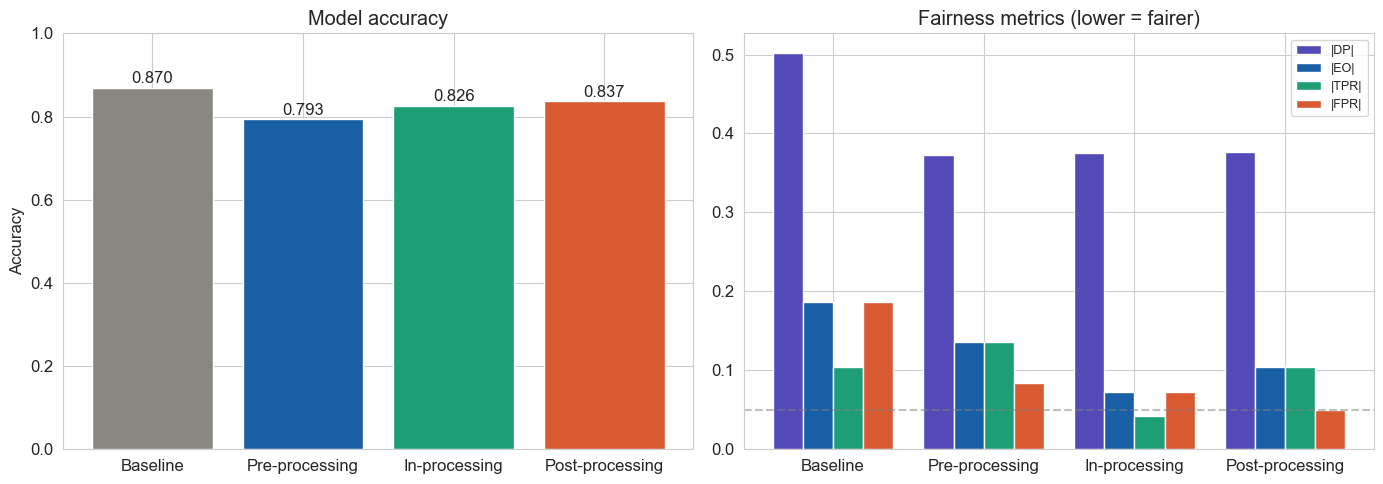

In [27]:
# Accuracy and fairness charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison_df['Model']
colors = ['#888780', '#185FA5', '#1D9E75', '#D85A30']

axes[0].bar(models, comparison_df['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

x = np.arange(len(models))
w = 0.2
axes[1].bar(x-1.5*w, comparison_df['DP_Diff'].abs(), w, label='|DP|', color='#534AB7')
axes[1].bar(x-0.5*w, comparison_df['EO_Diff'].abs(), w, label='|EO|', color='#185FA5')
axes[1].bar(x+0.5*w, comparison_df['TPR_Diff'].abs(), w, label='|TPR|', color='#1D9E75')
axes[1].bar(x+1.5*w, comparison_df['FPR_Diff'].abs(), w, label='|FPR|', color='#D85A30')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title('Fairness metrics (lower = fairer)')
axes[1].legend(fontsize=9)
axes[1].axhline(y=0.05, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

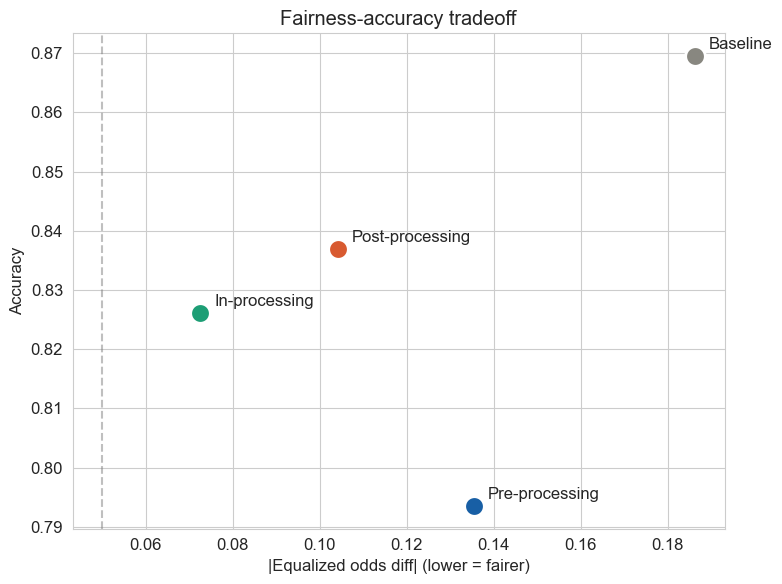

Ideal model is top-left (high accuracy, low bias).
Moving left from Baseline shows the cost of fairness.


In [28]:
# Fairness-accuracy tradeoff scatter
fig, ax = plt.subplots(figsize=(8, 6))
for i, (model, acc, eo) in enumerate(
    zip(models, comparison_df['Accuracy'], comparison_df['EO_Diff'].abs())):
    ax.scatter(eo, acc, s=200, c=colors[i], zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(model, (eo, acc), textcoords='offset points', xytext=(10, 5), fontsize=12)
ax.set_xlabel('|Equalized odds diff| (lower = fairer)')
ax.set_ylabel('Accuracy')
ax.set_title('Fairness-accuracy tradeoff')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('Ideal model is top-left (high accuracy, low bias).')
print('Moving left from Baseline shows the cost of fairness.')

---
## Step 8: Summary of findings

In [29]:
print('=' * 70)
print('SUMMARY OF FINDINGS')
print('=' * 70)

print(f'\n1. DATASET')
print(f'   Total patients: {len(data)}')
print(f'   Male: {int(data["sex_binary"].sum())}, Female: {int((data["sex_binary"]==0).sum())}')
print(f'   Heart disease prevalence: {data["HeartDisease"].mean()*100:.1f}%')
print(f'   Key issue: women underrepresented (only {int((data["sex_binary"]==0).sum())} vs {int(data["sex_binary"].sum())} males)')

print(f'\n2. BASELINE MODEL BIAS')
print(f'   Accuracy:       {baseline_fairness["accuracy"]:.4f}')
print(f'   EO difference:  {baseline_fairness["eo_diff"]:+.4f}')
print(f'   TPR difference: {baseline_fairness["tpr_diff"]:+.4f} (M-F)')
print(f'   FPR difference: {baseline_fairness["fpr_diff"]:+.4f} (M-F)')

print(f'\n3. EXPLAINABILITY (WHITEBOX + SHAP)')
print(f'   Sex coefficient: {baseline_model.coef_[0][sex_idx]:+.4f}')
print(f'   Proxy features: {proxy_features}')
print(f'   The whitebox model let us directly read the sex coefficient,')
print(f'   confirming the model uses sex in predictions.')
print(f'   SHAP confirmed differential feature importance by sex.')

print(f'\n4. DEBIASING RESULTS')
print(comparison_df[['Model', 'Accuracy', 'EO_Diff']].round(4).to_string(index=False))

debiased = comparison_df.iloc[1:]
best = debiased.loc[debiased['EO_Diff'].abs().idxmin()]
acc_cost = comparison_df.iloc[0]['Accuracy'] - best['Accuracy']

print(f'\n   Best fairness: {best["Model"]}')
print(f'   EO diff: {best["EO_Diff"]:+.4f} (baseline: {baseline_fairness["eo_diff"]:+.4f})')
print(f'   Accuracy cost: {acc_cost:+.4f}')

print(f'\n5. CLINICAL IMPLICATIONS')
print(f'   False negatives (missed heart disease) are especially dangerous')
print(f'   for women, who already face underdiagnosis in cardiology.')
print(f'   A biased model that misses female heart disease reinforces')
print(f'   existing clinical disparities.')

print(f'\n   As our professor noted, accuracy cost is acceptable —')
print(f'   the goal was to detect, explain, and reduce gender bias.')
print('\n' + '=' * 70)

SUMMARY OF FINDINGS

1. DATASET
   Total patients: 918
   Male: 725, Female: 193
   Heart disease prevalence: 55.3%
   Key issue: women underrepresented (only 193 vs 725 males)

2. BASELINE MODEL BIAS
   Accuracy:       0.8696
   EO difference:  +0.1863
   TPR difference: +0.1042 (M-F)
   FPR difference: +0.1863 (M-F)

3. EXPLAINABILITY (WHITEBOX + SHAP)
   Sex coefficient: +0.4765
   Proxy features: ['Sex', 'Cholesterol', 'MaxHR', 'ExerciseAngina', 'ST_Slope']
   The whitebox model let us directly read the sex coefficient,
   confirming the model uses sex in predictions.
   SHAP confirmed differential feature importance by sex.

4. DEBIASING RESULTS
          Model  Accuracy  EO_Diff
       Baseline    0.8696   0.1863
 Pre-processing    0.7935   0.1354
  In-processing    0.8261   0.0725
Post-processing    0.8370   0.1042

   Best fairness: In-processing
   EO diff: +0.0725 (baseline: +0.1863)
   Accuracy cost: +0.0435

5. CLINICAL IMPLICATIONS
   False negatives (missed heart disease)